# Sensor Anomaly Risk Evaluation Using Monte Carlo Simulation

This notebook demonstrates an end-to-end risk evaluation workflow for sensor anomaly monitoring using fully synthetic data.

The analysis focuses on:

- threshold estimation from normal-operation calibration data
- false positive and false negative trade-offs
- Monte Carlo resampling to evaluate threshold stability
- decision-cost sensitivity under different missed-anomaly costs

All data and parameters in this project are synthetic and were independently created for educational and portfolio purposes.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from data_generator import generate_sensor_data, METRIC_NAMES
from threshold_methods import (
    split_calibration_evaluation,
    get_all_threshold_methods
)
from evaluation import (
    apply_thresholds,
    calculate_classification_metrics
)
from monte_carlo_stability import (
    run_monte_carlo_stability,
    summarize_monte_carlo
)

## 1. Problem

Sensor monitoring systems often rely on alert thresholds estimated from historical normal-operation data.

However, threshold estimates can change depending on which calibration observations are used. This sampling variability can affect downstream anomaly detection performance.

This case study asks:

1. How do different thresholding methods trade off false alarms and missed anomalies?
2. How stable are those thresholds across repeated calibration samples?
3. How should the preferred method change when missed anomalies are more costly than false alarms?

In [2]:
df = generate_sensor_data(
    n_normal=500,
    n_anomaly=100,
    random_seed=42
)

print(f"Dataset shape: {df.shape}")
print("\nClass counts:")
print(df["is_anomaly"].value_counts())

df.head()

Dataset shape: (600, 5)

Class counts:
is_anomaly
0    500
1    100
Name: count, dtype: int64


,observation_id,temperature,vibration,power,is_anomaly
0,OBS_0001,70.019946,3.112705,87.497636,0
1,OBS_0002,76.475195,3.464113,99.059089,0
2,OBS_0003,76.129511,2.533517,114.357398,1
3,OBS_0004,72.094977,2.623628,104.489310,0
4,OBS_0005,69.336732,3.068516,101.608238,0


## 2. Synthetic Sensor Data

The dataset contains three correlated sensor metrics:

- Temperature
- Vibration
- Power

Each observation has a ground-truth label:

- `0` = normal operation
- `1` = anomaly

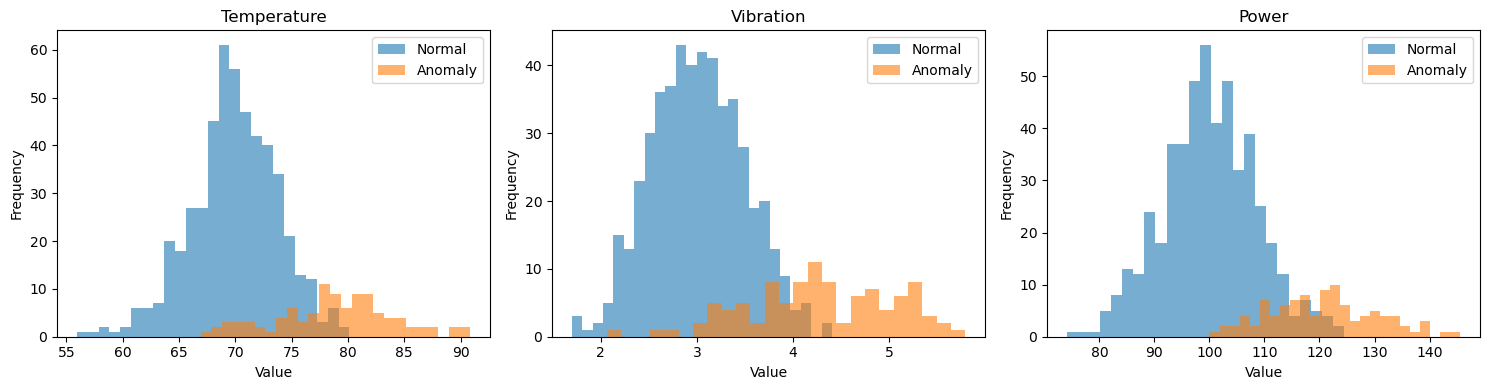

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, METRIC_NAMES):

    normal_values = df.loc[
        df["is_anomaly"] == 0,
        metric
    ]

    anomaly_values = df.loc[
        df["is_anomaly"] == 1,
        metric
    ]

    ax.hist(
        normal_values,
        bins=25,
        alpha=0.6,
        label="Normal"
    )

    ax.hist(
        anomaly_values,
        bins=25,
        alpha=0.6,
        label="Anomaly"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Calibration-Based Threshold Estimation

A calibration set of 60 known-normal observations is used to estimate alert thresholds.

The remaining observations are treated as the evaluation population.

In [4]:
calibration_df, evaluation_df = split_calibration_evaluation(
    df,
    calibration_size=60,
    random_seed=42
)

print("Calibration shape:", calibration_df.shape)
print("Evaluation shape:", evaluation_df.shape)

print("\nEvaluation class counts:")
print(evaluation_df["is_anomaly"].value_counts())

Calibration shape: (60, 5)
Evaluation shape: (540, 5)

Evaluation class counts:
is_anomaly
0    440
1    100
Name: count, dtype: int64


## 4. Compare Thresholding Methods

Four threshold estimation methods are evaluated:

- Mean + 2.5 × Standard Deviation
- Median + 2.5 × Standard Deviation
- 99th Percentile
- Median + 3 × Scaled MAD

In [5]:
threshold_methods = get_all_threshold_methods(
    calibration_df,
    METRIC_NAMES
)

threshold_table = pd.DataFrame(
    threshold_methods
).T

threshold_table

,temperature,vibration,power
mean_std,78.830378,3.972235,118.050548
median_std,78.761072,3.944163,118.652030
quantile_99,75.765123,3.979510,114.960873
median_mad,80.061424,3.828719,124.260782


In [6]:
rows = []

for method_name, thresholds in threshold_methods.items():

    result_df = apply_thresholds(
        evaluation_df,
        thresholds,
        METRIC_NAMES
    )

    metrics = calculate_classification_metrics(
        result_df
    )

    rows.append({
        "method": method_name,
        "false_positive_rate":
            metrics["false_positive_rate"],
        "false_negative_rate":
            metrics["false_negative_rate"],
        "precision":
            metrics["precision"],
        "recall":
            metrics["recall"]
    })

single_run_df = pd.DataFrame(rows)

single_run_df

,method,false_positive_rate,false_negative_rate,precision,recall
0,mean_std,0.052273,0.14,0.788991,0.86
1,median_std,0.047727,0.14,0.803738,0.86
2,quantile_99,0.122727,0.05,0.637584,0.95
3,median_mad,0.059091,0.19,0.757009,0.81


The thresholding methods produce different operating trade-offs.

A more aggressive threshold can detect more anomalies, but may also generate more false alarms. A more conservative threshold can reduce false alarms while increasing missed-anomaly risk.

A single calibration split, however, does not show how sensitive these results are to sampling variability.

## 5. Monte Carlo Threshold Stability Analysis

To evaluate calibration uncertainty, the calibration process is repeated 1,000 times.

For each iteration:

1. 60 normal observations are randomly selected.
2. All four thresholding methods are recalculated.
3. The thresholds are applied to the evaluation population.
4. Detection performance and threshold values are recorded.

This allows us to evaluate both average performance and variability across calibration samples.

In [7]:
mc_results = run_monte_carlo_stability(
    n_iterations=1000,
    calibration_size=60,
    random_seed=42
)

mc_summary = summarize_monte_carlo(
    mc_results
)

mc_summary.round(4)

,method,temperature_threshold_mean,temperature_threshold_std,vibration_threshold_mean,vibration_threshold_std,power_threshold_mean,power_threshold_std,false_positive_rate_mean,false_positive_rate_std,false_negative_rate_mean,false_negative_rate_std,precision_mean,recall_mean
0,mean_std,79.4491,0.9370,4.2081,0.1169,121.0186,2.1414,0.0228,0.0127,0.2402,0.0554,0.8890,0.7598
1,median_mad,80.6141,1.7191,4.5057,0.2256,124.1442,3.8209,0.0109,0.0122,0.3505,0.0837,0.9412,0.6495
2,median_std,79.4933,1.0222,4.1991,0.1203,120.9530,2.2360,0.0235,0.0134,0.2374,0.0567,0.8865,0.7625
3,quantile_99,77.5942,1.1207,4.0044,0.1414,118.3425,2.7123,0.0682,0.0328,0.1184,0.0421,0.7582,0.8816


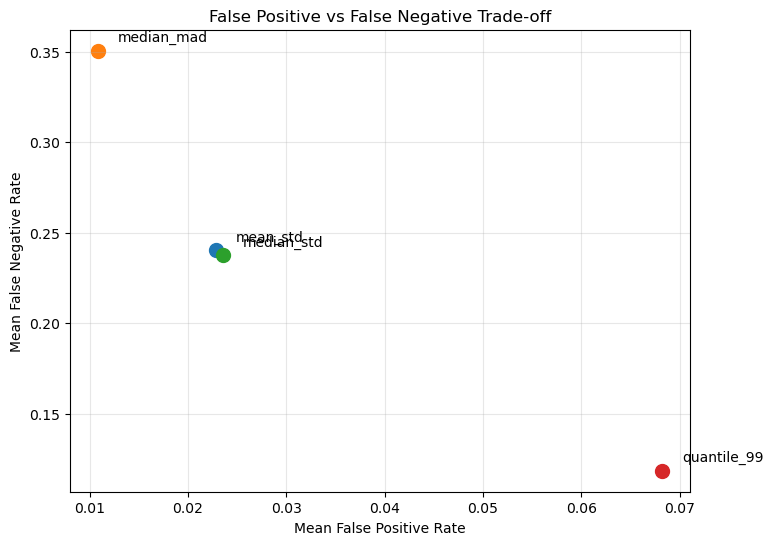

In [8]:
plt.figure(figsize=(8, 6))

for _, row in mc_summary.iterrows():

    plt.scatter(
        row["false_positive_rate_mean"],
        row["false_negative_rate_mean"],
        s=100
    )

    plt.text(
        row["false_positive_rate_mean"] + 0.002,
        row["false_negative_rate_mean"] + 0.005,
        row["method"]
    )

plt.xlabel("Mean False Positive Rate")
plt.ylabel("Mean False Negative Rate")
plt.title("False Positive vs False Negative Trade-off")
plt.grid(alpha=0.3)

plt.show()

The Monte Carlo results reveal a clear trade-off:

- The 99th-percentile method produces higher recall and fewer missed anomalies, but more false alarms.
- The Median + MAD method produces fewer false alarms, but misses more anomalies.
- Mean + SD and Median + SD provide more balanced performance.

The analysis also shows that threshold stability differs across estimation methods.

/var/folders/pd/90gdj1nn09d1l70p1t6n4jw40000gn/T/ipykernel_24336/1327726901.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


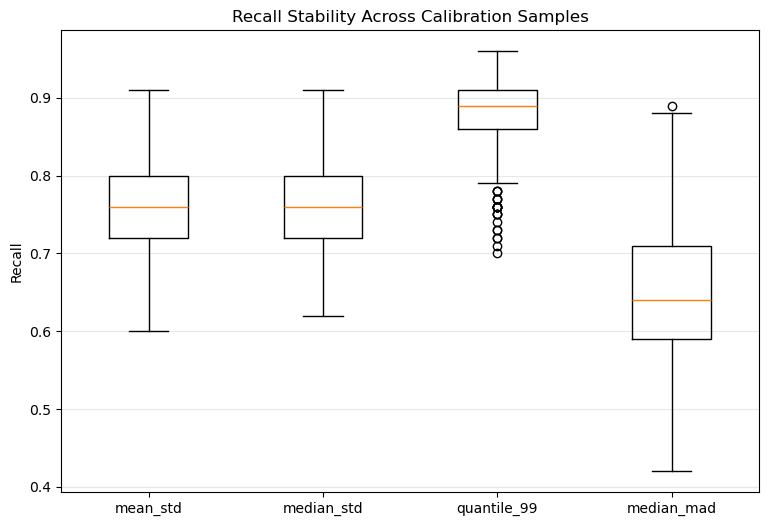

In [9]:
methods = mc_results["method"].unique()

recall_data = [
    mc_results.loc[
        mc_results["method"] == method,
        "recall"
    ].to_numpy()
    for method in methods
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    recall_data,
    labels=methods
)

plt.ylabel("Recall")
plt.title(
    "Recall Stability Across Calibration Samples"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

## 6. Cost-Sensitive Decision Analysis

False alarms and missed anomalies may have different operational consequences.

A simple synthetic cost function is defined as:

$$
\text{Decision Cost}
=
FP
+
C_{FN} \times FN
$$

where false-positive cost is fixed at 1 and the missed-anomaly cost is varied.

In [10]:
single_counts = []

for method_name, thresholds in threshold_methods.items():

    result_df = apply_thresholds(
        evaluation_df,
        thresholds,
        METRIC_NAMES
    )

    metrics = calculate_classification_metrics(
        result_df
    )

    single_counts.append({
        "method": method_name,
        "FP": metrics["FP"],
        "FN": metrics["FN"]
    })

counts_df = pd.DataFrame(single_counts)

fn_cost_values = [
    1, 2, 3, 3.5, 3.67, 4, 5, 10, 20
]

cost_rows = []

for fn_cost in fn_cost_values:

    for _, row in counts_df.iterrows():

        expected_cost = (
            row["FP"]
            + fn_cost * row["FN"]
        )

        cost_rows.append({
            "method": row["method"],
            "fn_cost": fn_cost,
            "expected_cost": expected_cost
        })

cost_df = pd.DataFrame(cost_rows)

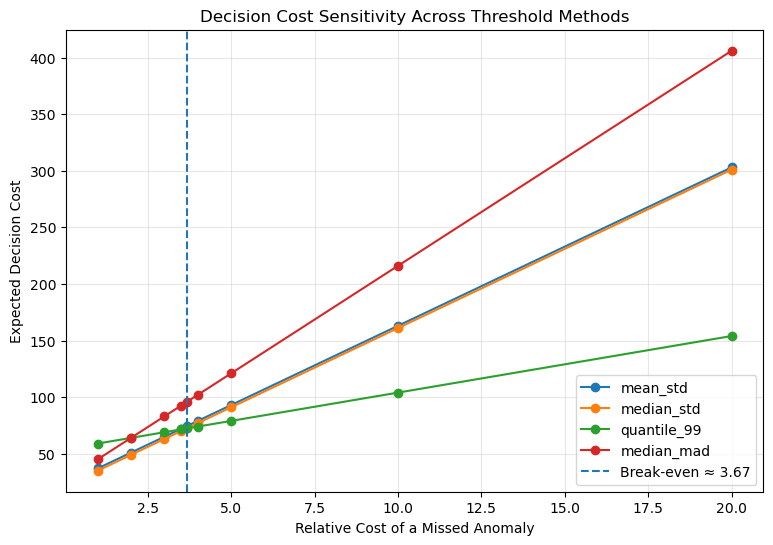

In [11]:
plt.figure(figsize=(9, 6))

for method in cost_df["method"].unique():

    method_df = cost_df[
        cost_df["method"] == method
    ]

    plt.plot(
        method_df["fn_cost"],
        method_df["expected_cost"],
        marker="o",
        label=method
    )

plt.axvline(
    3.67,
    linestyle="--",
    linewidth=1.5,
    label="Break-even ≈ 3.67"
)

plt.xlabel(
    "Relative Cost of a Missed Anomaly"
)

plt.ylabel(
    "Expected Decision Cost"
)

plt.title(
    "Decision Cost Sensitivity Across Threshold Methods"
)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Key Takeaways

This case study shows that threshold selection should be evaluated as a risk-management problem rather than only as a statistical estimation problem.

Key findings include:

- Alert thresholds vary across calibration samples.
- Different thresholding methods create materially different false-positive / false-negative trade-offs.
- Monte Carlo resampling helps quantify threshold and detection-performance uncertainty.
- A method that is robust to outliers is not necessarily the most stable under sampling variation.
- The preferred thresholding method depends on the operational cost of missed anomalies relative to false alarms.
- In this synthetic scenario, the preferred strategy shifts when the missed-anomaly cost reaches approximately 3.67 times the false-alarm cost.

## Future Extensions

Potential extensions include:

- varying calibration sample size
- testing different metric-correlation structures
- bootstrap confidence intervals
- multivariate anomaly scoring
- supervised anomaly-detection models
- optimization of threshold parameters